<a href="https://colab.research.google.com/github/alex-degarate/DAnalytics/blob/main/After_10/AC10_graficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA - Visualización

**Visualización de datos y creación de resúmenes estadísticos.**
<BR>

Hacer visualizaciones informativas (también llamadas gráficos o plots) es una de las tareas más importantes en el análisis de datos.
Estas visualizaciones pueden tener distintos propósitos:

* Exploratorio: para detectar valores atípicos (outliers), identificar la necesidad de transformar datos o generar ideas para modelos.

* Comunicativo o final: en algunos casos, el objetivo es construir una visualización interactiva (por ejemplo, para la web) como producto final del análisis.
<BR>

Python ofrece muchas bibliotecas para crear visualizaciones estáticas o dinámicas. Sin embargo, la más importante es Matplotlib, y muchas otras herramientas se basan en ella. Por ello veremos también Seaborn (sns)

Armamos una función que genera/simula calificaciones de estudiantes

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
from scipy.stats import truncnorm
import numpy as np

def gen_notas(media, desvio, n, minimo=1, maximo=10):
    """
    Genera una distribución normal truncada entre 'minimo' y 'maximo'.

    Parámetros:
    -----------
    media : float
        Media (mu) de la distribución.
    desvio : float
        Desviación estándar (sigma).
    n : int
        Número de observaciones a generar.
    minimo : float, opcional
        Valor mínimo permitido (default = 1).
    maximo : float, opcional
        Valor máximo permitido (default = 10).

    Retorna:
    --------
    np.ndarray
        Array de NumPy con los valores generados.
    """
    # Calcular los límites normalizados
    a, b = (minimo - media) / desvio, (maximo - media) / desvio

    # Generar muestra truncada
    muestra = truncnorm(a, b, loc=media, scale=desvio).rvs(n).round(1)

    return np.array(muestra)

## Ejemplo de visualización con Matplotlib


### Generar variables y valores

In [4]:
# Generamos notas para un grupo de estudiantes, usando la funcion gen_notas()
# array = gen_notas(mean, desv, n)
notas = pd.DataFrame(
    {
        'grupo_1': gen_notas(8, 1, 1000),
        'grupo_2': gen_notas(6, 2, 1000)
    }
)
#notas.describe()

### Histograma comparativo - Versión 1

In [5]:
# Veamos un resumen estadístico
#notas.describe()

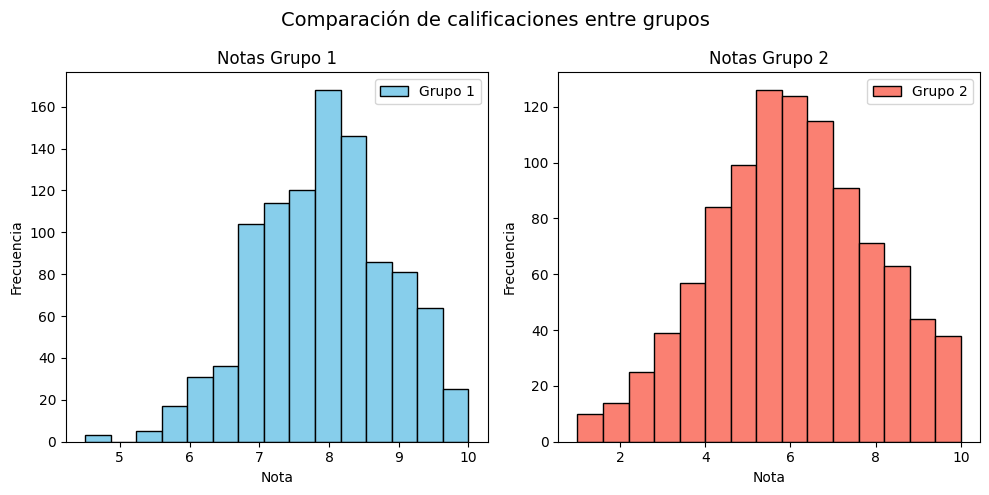

In [6]:
# Queremos hacer un gráfico, pero comparativo
fig = plt.figure(figsize=(10,5))

# Crear los dos subplots
gp1 = fig.add_subplot(1, 2, 1)
gp2 = fig.add_subplot(1, 2, 2)

# Histograma para el grupo 1
gp1.hist(notas["grupo_1"], bins=15, color='skyblue', edgecolor='black', label="Grupo 1")
gp1.set_title("Notas Grupo 1")
gp1.set_xlabel("Nota")
gp1.set_ylabel("Frecuencia")
gp1.legend()

# Histograma para el grupo 2
gp2.hist(notas["grupo_2"], bins=15, color='salmon', edgecolor='black', label="Grupo 2")
gp2.set_title("Notas Grupo 2")
gp2.set_xlabel("Nota")
gp2.set_ylabel("Frecuencia")
gp2.legend()

# Título general
fig.suptitle("Comparación de calificaciones entre grupos", fontsize=14)

plt.tight_layout()
plt.show()


### Histograma comparativo - Versión 2

In [ ]:
# Queremos hacer un gráfico, pero comparativo
plt.figure(figsize=(10,5))

# Crear los dos subplots
plt.subplot(1, 2, 1)
plt.hist(notas["grupo_1"], bins=15, color='skyblue', edgecolor='black', label="Grupo 1")
plt.title("Grupo 1")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")
plt.legend()

# Histograma para el grupo 2
plt.subplot(1, 2, 2)
plt.hist(notas["grupo_2"], bins=15, color='salmon', edgecolor='black', label="Grupo 2")
plt.title("Grupo 2")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")
plt.legend()

# Título general
plt.suptitle("Comparación de calificaciones entre grupos", fontsize=14)

plt.tight_layout()
plt.show()


### Boxplot simple

In [ ]:
# Veamos como graficar un boxplot
plt.boxplot(notas["grupo_1"], label="Grupo 1")
# plt.boxplot(
#     notas["grupo_1"],
#     patch_artist=True,                # habilita color de relleno
#     boxprops=dict(facecolor="skyblue", color="blue"),  # color de la caja
#     medianprops=dict(color="red"),    # color de la línea de la mediana
#     whiskerprops=dict(color="blue"),  # color de los bigotes
#     capprops=dict(color="blue"),      # color de las “tapitas”
# )
plt.legend()
plt.title("Boxplot de notas")
plt.xlabel("Grupo")
plt.ylabel("Nota")
plt.show()

## Ejemplo de visualización con Seaborn

Seaborn, que se basa en Matplotlib, ofrece una interfaz más sencilla para crear
gráficos estadísticos. Continuando con nuestro conjunto de datos anterior, podemos
usar Seaborn para crear un gráfico de distribución.


Sintaxis:
<BR>
`sns.barplot(x='columna_x', y='columna_y', data=df)`

Ventajas de sns.histplot()

* Integra directamente con pandas (solo pasás data= , x=).
* Tiene parámetros como hue, kde, stat, etc.
* Estéticamente más agradable (usa el estilo por defecto de Seaborn).

### Histograma simple

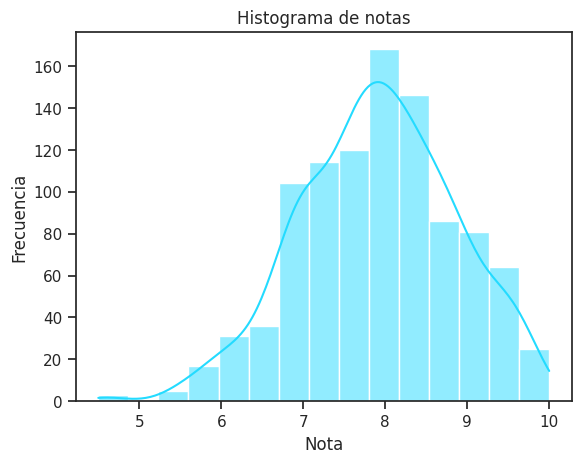

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")  # "whitegrid," "darkgrid", "white", "ticks", "dark"
sns.set_palette("cool") # "pastet", "deep", "coolwarm", "husl"

sns.histplot(
    data=notas,          # DataFrame que contiene los datos
    x="grupo_1",         # Columna a graficar
    bins=15,             # Cantidad de barras
    # color="blue",        # Color de relleno
    # alpha=0.5,           # Opacidad (igual que en Matplotlib)
    kde=True
)

plt.title("Histograma de notas")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")
plt.show()


### Histograma comparativo - Version 1

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks", palette="cool")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Primer gráfico
sns.histplot(data=notas, x="grupo_1", bins=15, kde=True, color="steelblue", ax=ax1)
ax1.set_title("Grupo 1")
ax1.set_xlabel("Nota")
ax1.set_ylabel("Frecuencia")

# Segundo gráfico
sns.histplot(data=notas, x="grupo_2", bins=15, kde=True, color="salmon", ax=ax2)
ax2.set_title("Grupo 2")
ax2.set_xlabel("Nota")
ax2.set_ylabel("Frecuencia")

fig.suptitle("Comparación de calificaciones entre grupos", fontsize=14)
plt.tight_layout()
plt.show()


### Histograma comparativo - Versión 2

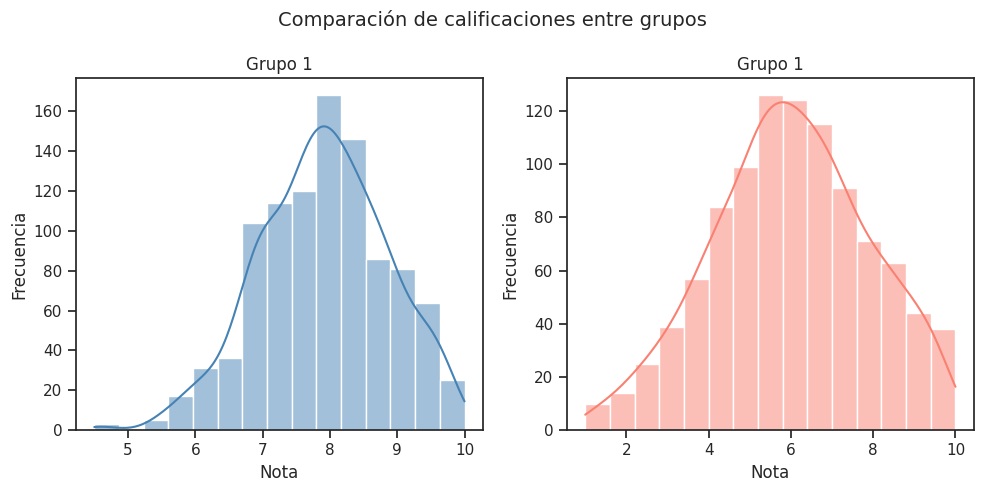

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks", palette="cool")

plt.figure(figsize=(10, 5))

# Primer gráfico
plt.subplot(1, 2, 1)
sns.histplot(data=notas, x="grupo_1", bins=15, kde=True, color="steelblue")
plt.title("Grupo 1")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")

# Segundo gráfico
plt.subplot(1, 2, 2)
sns.histplot(data=notas, x="grupo_2", bins=15, kde=True, color="salmon")
plt.title("Grupo 1")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")

plt.suptitle("Comparación de calificaciones entre grupos", fontsize=14)
plt.tight_layout()
plt.show()


### Boxplot simple

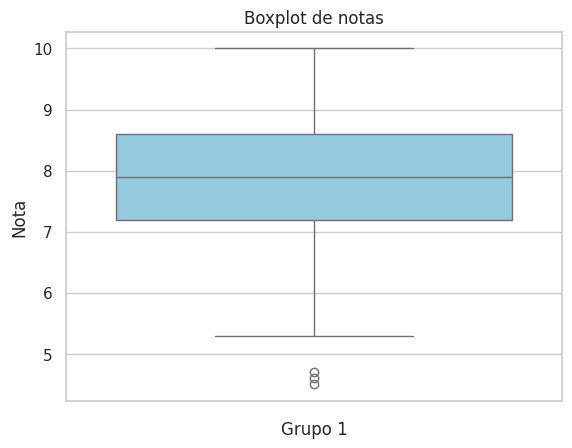

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.reset_defaults()
sns.set_theme(style="whitegrid")  # estilo con fondo claro y rejilla

# sns.boxplot(
#     notas["grupo_1"]
# )

sns.boxplot(
    data=notas,
    y="grupo_1",            # columna a graficar
    color="skyblue"         # color de la caja
)

plt.title("Boxplot de notas")
plt.xlabel("Grupo 1")
plt.ylabel("Nota")
plt.show()


### Boxplot comparativo

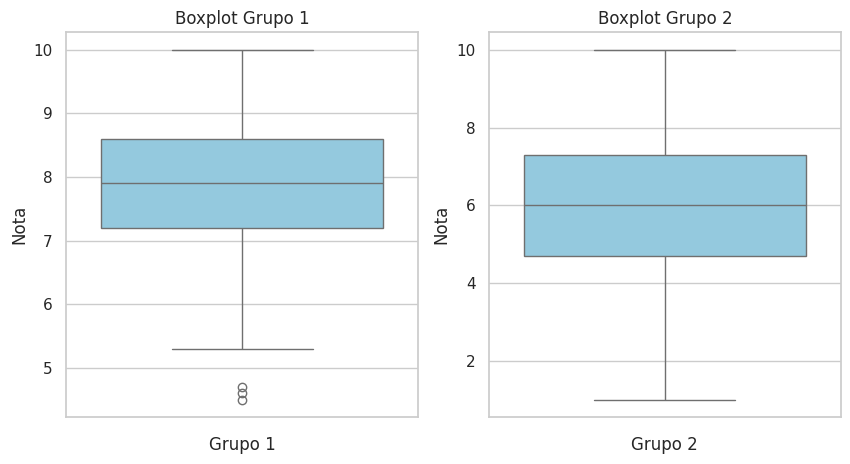

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.reset_defaults()
sns.set_theme(style="whitegrid", palette="cool")

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)

sns.boxplot(
    data=notas,
    y="grupo_1",            # columna a graficar
    color="skyblue"         # color de la caja
)
plt.title("Boxplot Grupo 1")
plt.xlabel("Grupo 1")
plt.ylabel("Nota")

plt.subplot(1,2,2)
sns.boxplot(
    data=notas,
    y="grupo_2",            # columna a graficar
    color="skyblue"         # color de la caja
)
plt.title("Boxplot Grupo 2")
plt.xlabel("Grupo 2")
plt.ylabel("Nota")

plt.show()


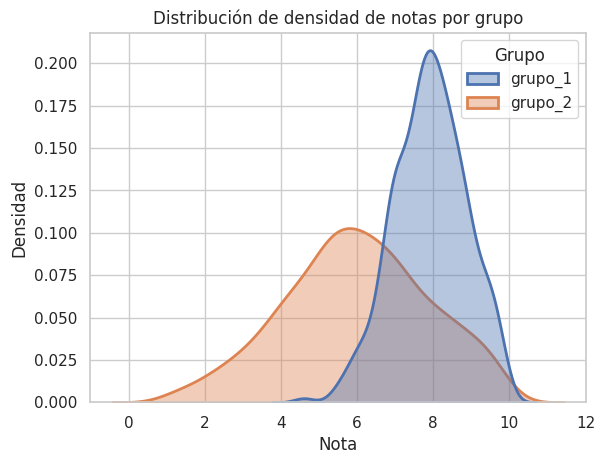

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reestructuramos el DataFrame a formato largo
melted = notas.melt(var_name="Grupo", value_name="Nota")

sns.kdeplot(
    data=melted,
    x="Nota",
    hue="Grupo",        # separa las curvas por grupo
    fill=True,          # rellena el área bajo la curva
    alpha=0.4,          # transparencia
    linewidth=2
)

plt.title("Distribución de densidad de notas por grupo")
plt.xlabel("Nota")
plt.ylabel("Densidad")
plt.show()
